In [1]:
# Check GPU
!nvidia-smi

Thu Jul  9 06:26:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
!pip install -q -U transformers accelerate peft trl datasets bitsandbytes

In [4]:
import transformers, peft, trl, torch
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("trl:", trl.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


transformers: 5.13.0
peft: 0.19.1
trl: 1.7.1
torch: 2.10.0+cu128
CUDA available: True


In [5]:
import os

# List the dataset folder to find the exact file
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/thedevastator/alpaca-language-instruction-training/train.csv


In [6]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/thedevastator/alpaca-language-instruction-training/train.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (51760, 3)

Columns: ['instruction', 'output', 'input']

First 3 rows:


,instruction,output,input
0,Give three tips for staying healthy.,1. Eat a balanced and nutritious diet: Make su...,NaN
1,What are the three primary colors?,"The three primary colors are red, blue, and ye...",NaN
2,Describe the structure of an atom.,An atom is the basic building block of all mat...,NaN


In [7]:
import numpy as np

# Random sample for reproducibility
df_sample = df.sample(n=2000, random_state=42).reset_index(drop=True)
df_sample['input'] = df_sample['input'].fillna('')  # replace NaN with empty string

print("Sampled shape:", df_sample.shape)
print("\nHow many have non-empty input:", (df_sample['input'] != '').sum())
print("\nExample with input:")
example_with_input = df_sample[df_sample['input'] != ''].iloc[0]
print("Instruction:", example_with_input['instruction'])
print("Input:", example_with_input['input'])
print("Output:", example_with_input['output'])

Sampled shape: (2000, 3)

How many have non-empty input: 713

Example with input:
Instruction: Rewrite the given poem so that it rhymes
Input: This world was far from perfect,
As the shadows have shown.
The wickedness won’t relent,
As the risks have grown.
Output: This world was far from ideal,
As the darkness did reveal.
Wickedness refused to yield,
As dangers in the shadows peeled.


In [8]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def format_example(row):
    # Merge instruction + input into a single user message
    if row['input'].strip() != '':
        user_content = f"{row['instruction']}\n\n{row['input']}"
    else:
        user_content = row['instruction']
    
    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": row['output']}
    ]
    
    # apply_chat_template formats this into Qwen's expected format
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    return text

# Test on one example
sample_formatted = format_example(df_sample.iloc[0])
print(sample_formatted)

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
How can you use technology to improve your customer service?<|im_end|>
<|im_start|>assistant
There are several ways technology can be used to improve customer service, including the following:

1. Implementing Chatbots: Chatbots can help provide a faster, more personalized service to your customers. Equipped with artificial intelligence and natural language processing algorithms, chatbots can quickly respond to customer queries, saving customers time and providing them with immediate assistance.

2. Using Social Media: Using social media platforms to interact with customers is an excellent way to improve customer service. By maintaining an active presence on social media, companies can respond to messages and comments promptly, providing customers with an additional, convenient way to reach out for support.

3. Creating a customer-centered website: The company's website sh

In [9]:
from datasets import Dataset

# Apply formatting to all rows
df_sample['text'] = df_sample.apply(format_example, axis=1)

# Quick check of length distribution (helps confirm our max_seq_length=512 choice)
text_lengths = df_sample['text'].apply(lambda x: len(tokenizer(x)['input_ids']))
print("Token length stats:")
print(text_lengths.describe())
print("\n% of examples over 512 tokens:", (text_lengths > 512).mean() * 100)

# Convert to HF Dataset
train_dataset = Dataset.from_pandas(df_sample[['text']])
print("\nDataset ready:", train_dataset)

Token length stats:
count    2000.000000
mean      191.662000
std       129.324418
min        42.000000
25%        77.000000
50%       156.000000
75%       279.000000
max      1055.000000
Name: text, dtype: float64

% of examples over 512 tokens: 1.7999999999999998

Dataset ready: Dataset({
    features: ['text'],
    num_rows: 2000
})


In [10]:
import torch
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,   # fp16 to save memory on T4
    device_map="cuda:0"          # use single GPU
)

print(model)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [11]:
!pip install -q -U torchao

In [12]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


In [13]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="/kaggle/working/qwen_lora_checkpoints",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch size = 16
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=10,
    save_strategy="epoch",
    max_length=512,
    dataset_text_field="text",
    report_to="none",       # disable wandb prompts
    fp16=True,
)

trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
)

print("Trainer ready. Total training steps:", len(trainer.get_train_dataloader()) * training_args.num_train_epochs)

Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Trainer ready. Total training steps: 1500


In [14]:
import time

start_time = time.time()
train_result = trainer.train()
end_time = time.time()

training_duration = end_time - start_time
print(f"\nTraining completed in {training_duration/60:.2f} minutes")
print(f"Final training loss: {train_result.training_loss:.4f}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.975841
20,1.596148
30,1.360445
40,1.249190
50,1.231596
60,1.272014
70,1.240576
80,1.279918
90,1.185844
100,1.227068



Training completed in 11.04 minutes
Final training loss: 1.2518


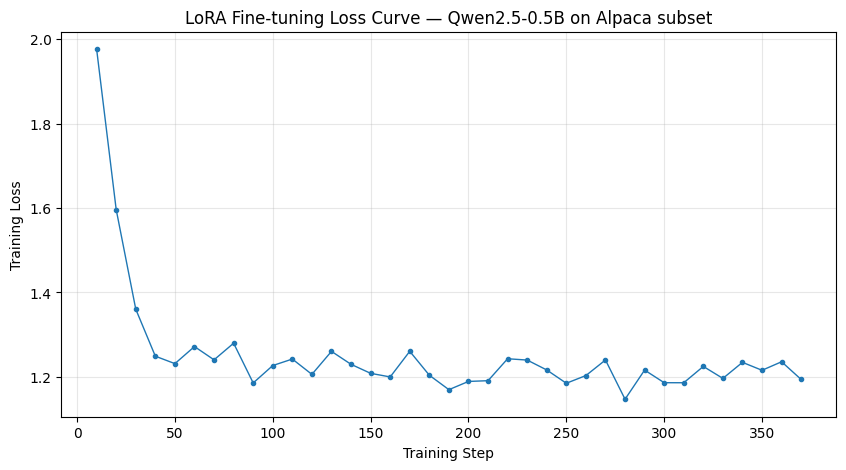

Loss curve saved. Min loss: 1.1473, Max loss: 1.9758


In [15]:
import matplotlib.pyplot as plt

# Extract loss history from the trainer
log_history = trainer.state.log_history
steps = [entry['step'] for entry in log_history if 'loss' in entry]
losses = [entry['loss'] for entry in log_history if 'loss' in entry]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, marker='o', markersize=3, linewidth=1)
plt.xlabel('Training Step')
plt.ylabel('Training Loss')
plt.title('LoRA Fine-tuning Loss Curve — Qwen2.5-0.5B on Alpaca subset')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Loss curve saved. Min loss: {min(losses):.4f}, Max loss: {max(losses):.4f}")

In [16]:
adapter_path = "/kaggle/working/qwen_lora_adapter"
peft_model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

# Check size of saved adapter
import os
total_size = 0
for dirpath, dirnames, filenames in os.walk(adapter_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

print(f"Adapter saved to: {adapter_path}")
print(f"Adapter size: {total_size / (1024*1024):.2f} MB")

# List files
for f in os.listdir(adapter_path):
    print(" -", f)

Adapter saved to: /kaggle/working/qwen_lora_adapter
Adapter size: 12.98 MB
 - chat_template.jinja
 - adapter_model.safetensors
 - adapter_config.json
 - tokenizer.json
 - tokenizer_config.json
 - README.md


In [17]:
from peft import PeftModel

# Reload base model fresh (clean copy, fp16)
base_model_for_merge = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="cuda:0"
)

# Load the adapter on top of it
merged_model = PeftModel.from_pretrained(base_model_for_merge, adapter_path)

# Merge adapter weights into the base model permanently
merged_model = merged_model.merge_and_unload()

print("Merge complete.")
print(type(merged_model))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Merge complete.
<class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>


In [18]:
merged_model_path = "/kaggle/working/qwen_merged_model"

merged_model.save_pretrained(merged_model_path)
tokenizer.save_pretrained(merged_model_path)

# Check size
total_size = 0
for dirpath, dirnames, filenames in os.walk(merged_model_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

print(f"Merged model saved to: {merged_model_path}")
print(f"Merged model size: {total_size / (1024*1024):.2f} MB")

for f in os.listdir(merged_model_path):
    print(" -", f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved to: /kaggle/working/qwen_merged_model
Merged model size: 953.22 MB
 - chat_template.jinja
 - config.json
 - tokenizer.json
 - tokenizer_config.json
 - generation_config.json
 - model.safetensors


In [19]:
import gc

# Free up GPU memory from training
del model, peft_model, trainer, base_model_for_merge, merged_model
gc.collect()
torch.cuda.empty_cache()

print("GPU memory freed.")

GPU memory freed.


In [20]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch, time

cpu_model_path = "/kaggle/working/qwen_merged_model"

tokenizer_cpu = AutoTokenizer.from_pretrained(cpu_model_path)
cpu_model = AutoModelForCausalLM.from_pretrained(
    cpu_model_path,
    dtype=torch.float32,   # CPU inference typically uses fp32, not fp16
    device_map="cpu"
)

print("Model loaded on:", cpu_model.device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded on: cpu


In [21]:
base_model_path = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer_base = AutoTokenizer.from_pretrained(base_model_path)
base_model_cpu = AutoModelForCausalLM.from_pretrained(
    base_model_path,
    dtype=torch.float32,
    device_map="cpu"
)

print("Base model loaded on:", base_model_cpu.device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Base model loaded on: cpu


In [23]:
def generate_response(model, tokenizer, user_prompt, max_new_tokens=150):
    messages = [{"role": "user", "content": user_prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt")

    start = time.time()
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,       # greedy decoding for reproducible comparison
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )
    end = time.time()

    generated_tokens = output[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    duration = end - start
    num_tokens = len(generated_tokens)
    tokens_per_sec = num_tokens / duration if duration > 0 else 0

    return response, duration, num_tokens, tokens_per_sec

In [24]:
test_prompts = [
    "Give three tips for staying healthy.",
    "What are the three primary colors?",
    "Write a short poem about the ocean.",
    "Explain what machine learning is in simple terms.",
    "List two benefits of regular exercise."
]

results = []

for prompt in test_prompts:
    print(f"\n{'='*80}\nPROMPT: {prompt}\n{'='*80}")
    
    base_response, base_time, base_tokens, base_tps = generate_response(base_model_cpu, tokenizer_base, prompt)
    print(f"\n--- BASE MODEL (before fine-tuning) ---")
    print(base_response)
    print(f"[Time: {base_time:.2f}s | Tokens: {base_tokens} | Speed: {base_tps:.2f} tok/s]")
    
    ft_response, ft_time, ft_tokens, ft_tps = generate_response(cpu_model, tokenizer_cpu, prompt)
    print(f"\n--- FINE-TUNED MODEL (after LoRA) ---")
    print(ft_response)
    print(f"[Time: {ft_time:.2f}s | Tokens: {ft_tokens} | Speed: {ft_tps:.2f} tok/s]")
    
    results.append({
        'prompt': prompt,
        'base_response': base_response,
        'base_time': base_time,
        'base_tps': base_tps,
        'ft_response': ft_response,
        'ft_time': ft_time,
        'ft_tps': ft_tps
    })


PROMPT: Give three tips for staying healthy.

--- BASE MODEL (before fine-tuning) ---
Certainly! Staying healthy is crucial for maintaining good health and longevity. Here are three key tips to help you stay healthy:

1. **Regular Exercise**: Engaging in regular physical activity is one of the most effective ways to keep your body and mind healthy. Aim for at least 30 minutes of moderate exercise most days of the week. This could be anything from walking, jogging, cycling, swimming, or any other form of exercise that you enjoy.

2. **Adequate Sleep**: Ensuring you get enough sleep is essential for overall health. Adults typically need between seven and nine hours of sleep per night. Establishing a consistent bedtime routine can also help regulate your sleep patterns. Avoid screens before bed as they emit blue light which can
[Time: 16.66s | Tokens: 150 | Speed: 9.01 tok/s]

--- FINE-TUNED MODEL (after LoRA) ---
1. Exercise regularly: Regular physical activity is essential for maintain

In [26]:
# Redo properly: keep original indices until after the overlap check
remaining_df = df[~df.index.isin(train_indices)]
held_out_df = remaining_df.sample(n=100, random_state=123)

# Now check overlap using original indices, BEFORE resetting
overlap = set(held_out_df.index) & train_indices
print("True overlap (should be 0):", len(overlap))

# Only reset index after confirming no overlap
held_out_df = held_out_df.reset_index(drop=True)
held_out_df['input'] = held_out_df['input'].fillna('')

print("Held-out set size:", held_out_df.shape)

True overlap (should be 0): 0
Held-out set size: (100, 3)


In [27]:
def compute_perplexity(model, tokenizer, df, max_length=512):
    total_loss = 0.0
    total_tokens = 0
    
    model.eval()
    with torch.no_grad():
        for idx, row in df.iterrows():
            if row['input'].strip() != '':
                user_content = f"{row['instruction']}\n\n{row['input']}"
            else:
                user_content = row['instruction']
            
            messages = [
                {"role": "user", "content": user_content},
                {"role": "assistant", "content": row['output']}
            ]
            text = tokenizer.apply_chat_template(messages, tokenize=False)
            
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
            input_ids = inputs['input_ids']
            
            outputs = model(input_ids, labels=input_ids)
            
            # outputs.loss is average negative log-likelihood per token
            num_tokens = input_ids.shape[1]
            total_loss += outputs.loss.item() * num_tokens
            total_tokens += num_tokens
    
    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity, avg_loss

print("Computing perplexity for BASE model...")
base_ppl, base_avg_loss = compute_perplexity(base_model_cpu, tokenizer_base, held_out_df)
print(f"Base model perplexity: {base_ppl:.4f} (avg loss: {base_avg_loss:.4f})")

print("\nComputing perplexity for FINE-TUNED model...")
ft_ppl, ft_avg_loss = compute_perplexity(cpu_model, tokenizer_cpu, held_out_df)
print(f"Fine-tuned model perplexity: {ft_ppl:.4f} (avg loss: {ft_avg_loss:.4f})")

print(f"\nPerplexity improvement: {((base_ppl - ft_ppl) / base_ppl * 100):.2f}%")

Computing perplexity for BASE model...
Base model perplexity: 7.9508 (avg loss: 2.0733)

Computing perplexity for FINE-TUNED model...
Fine-tuned model perplexity: 3.3988 (avg loss: 1.2234)

Perplexity improvement: 57.25%


In [28]:
import shutil

# Zip the merged model
shutil.make_archive('/kaggle/working/qwen_merged_model', 'zip', '/kaggle/working/qwen_merged_model')

# Zip the adapter separately (much smaller, useful to keep too)
shutil.make_archive('/kaggle/working/qwen_lora_adapter', 'zip', '/kaggle/working/qwen_lora_adapter')

# Confirm
for f in os.listdir('/kaggle/working'):
    if f.endswith('.zip'):
        size_mb = os.path.getsize(f'/kaggle/working/{f}') / (1024*1024)
        print(f"{f}: {size_mb:.2f} MB")

qwen_lora_adapter.zip: 3.96 MB
qwen_merged_model.zip: 734.56 MB
